# Imports

In [1]:
import os
import warnings
from rich import print

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import palantir
import scvi
import torch

In [2]:
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline

# Functions

In [3]:
def log_transform(ad, ps=0.1):
    """
    Applies a pseudo-count log2 transformation to the data in an AnnData object.

    The transformation is defined as log2(x + ps) - log2(ps), where x is the original data
    and ps is the pseudo-count. The purpose of the pseudo-count is to avoid taking the log of zero.

    Parameters
    ----------
    ad: AnnData
        The AnnData object containing the data to be transformed.

    ps: float, optional
        The pseudo-count to be added to the data before taking the logarithm.
        The default value is 0.1.

    Returns
    -------
    None
        The function modifies the AnnData object in-place.
    """

    # Check if the data in the Anndata object is a numpy array
    if not isinstance(ad.X.data, np.ndarray):
        raise TypeError("The data in the AnnData object should be a numpy array.")

    # Check if the pseudo-count is a positive number
    if ps <= 0:
        raise ValueError("The pseudo-count should be a positive number.")

    # Apply the log2 transformation
    ad.X.data = np.log2(ad.X.data + ps) - np.log2(ps)

# Plate: Colon

In [4]:
input_dir = '/fh/fast/talbot_j/grp/TalbotLab/Current_Lab_Members/Brandon_Nguyen/Project/Results/BN007/datasets/Drokhlyansky et al/'

In [5]:
drok_metadata = pd.read_csv(input_dir + 'metadata.csv')
drok_metadata['mouse_and_sample_id'] = drok_metadata['Mouse_ID'] + '_' + drok_metadata['sample_id']
drok_metadata

,Mouse_ID,sample_id,Age,Segment (Processed),Sex,Technology,mouse_and_sample_id
0,M1,S1,12,colon,F,Plate,M1_S1
1,M2,S2,12,colon,M,Plate,M2_S2
2,M3,S3,12,colon,M,Plate,M3_S3
3,M4,S4,12,colon,M,Plate,M4_S4
4,M5,S5,12,colon,F,Plate,M5_S5
...,...,...,...,...,...,...,...
119,M5,S29,12,ileum,F,Droplet,M5_S29
120,M5,S30,12,ileum,F,Droplet,M5_S30
121,M6,S31,12,ileum,M,Droplet,M6_S31
122,M7,S27,12,ileum,F,Droplet,M7_S27


In [6]:
# Load in matrix to an AnnData object
ad_drok_plate = sc.read(input_dir + 'gene_sorted-ss2.neur.matrix.mtx')
ad_drok_plate

Only considering the two last: ['.matrix', '.mtx'].
Only considering the two last: ['.matrix', '.mtx'].


AnnData object with n_obs × n_vars = 21100 × 2657

In [7]:
barcodes = pd.read_csv(input_dir + 'ss2.neur.barcodes.tsv', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [8]:
barcodes['mouse_and_sample_id'] = barcodes['barcode'].str.split('_').str[1] + '_' + barcodes['barcode'].str.split('_').str[2]
barcodes['mouse_id'] = barcodes['barcode'].str.split('_').str[1]
barcodes['sample_id'] = barcodes['barcode'].str.split('_').str[2]
barcodes['sample_id'] = barcodes['sample_id'].str.split('.').str[0]

In [9]:
barcodes['mouse_and_sample_id'] = barcodes['mouse_id'] + '_' + barcodes['sample_id']

In [10]:
barcodes

,barcode,mouse_and_sample_id,mouse_id,sample_id
0,Atlas_M1_S1.S339,M1_S1,M1,S1
1,Atlas_M1_S1.S351,M1_S1,M1,S1
2,Atlas_M1_S1.S363,M1_S1,M1,S1
3,Atlas_M1_S1.S349,M1_S1,M1,S1
4,Atlas_M1_S1.S313,M1_S1,M1,S1
...,...,...,...,...
2652,Aging_M29_S102.S329,M29_S102,M29,S102
2653,Aging_M29_S102.S302,M29_S102,M29,S102
2654,Aging_M29_S102.S307,M29_S102,M29,S102
2655,Aging_M29_S102.S321,M29_S102,M29,S102


In [11]:
genes = pd.read_csv(input_dir + 'ss2.neur.genes.tsv', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_name'})

In [12]:
ad_drok_plate = ad_drok_plate.T 
ad_drok_plate.obs = barcodes
ad_drok_plate.var = genes
ad_drok_plate.var_names_make_unique()
ad_drok_plate

AnnData object with n_obs × n_vars = 2657 × 21100
    obs: 'barcode', 'mouse_and_sample_id', 'mouse_id', 'sample_id'
    var: 'gene_name'

In [13]:
ad_drok_plate.var_names = ad_drok_plate.var['gene_name']
ad_drok_plate.obs_names = ad_drok_plate.obs['barcode']
ad_drok_plate.layers['raw_counts'] = ad_drok_plate.X.copy()

In [14]:
ad_drok_plate.var["mt"] = ad_drok_plate.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    ad_drok_plate,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

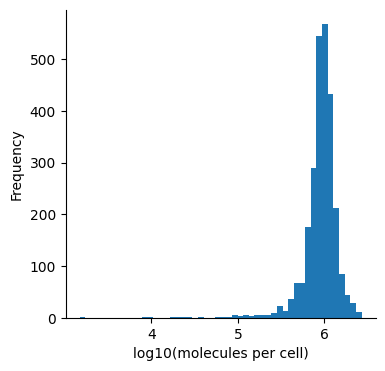

In [15]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_plate.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

In [16]:
ad_drok_plate.shape

(2657, 21100)

In [17]:
sc.pp.normalize_total(ad_drok_plate, target_sum=1e4)
ad_drok_plate.layers["normalized_counts"] = ad_drok_plate.X.copy()
log_transform(ad_drok_plate)
ad_drok_plate.layers["logcounts"] = ad_drok_plate.X.copy()

In [19]:
sc.pp.highly_variable_genes(ad_drok_plate, flavor="cell_ranger", n_top_genes=2500)

In [20]:
sc.tl.pca(ad_drok_plate, mask_var="highly_variable")

In [21]:
sc.pp.neighbors(ad_drok_plate, use_rep="X_pca")
sc.tl.umap(ad_drok_plate)

/loc/scratch/41954361/ipykernel_13448/3249849937.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ad_drok_plate, resolution=0.6, key_added="leiden")


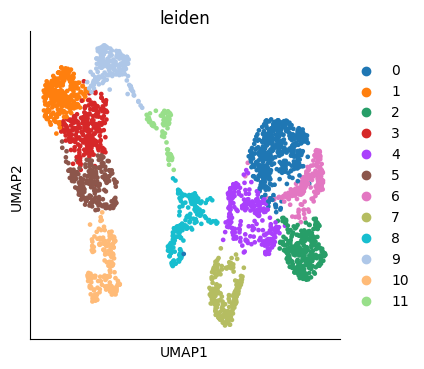

In [22]:
sc.tl.leiden(ad_drok_plate, resolution=0.6, key_added="leiden")
sc.pl.umap(ad_drok_plate, color="leiden")

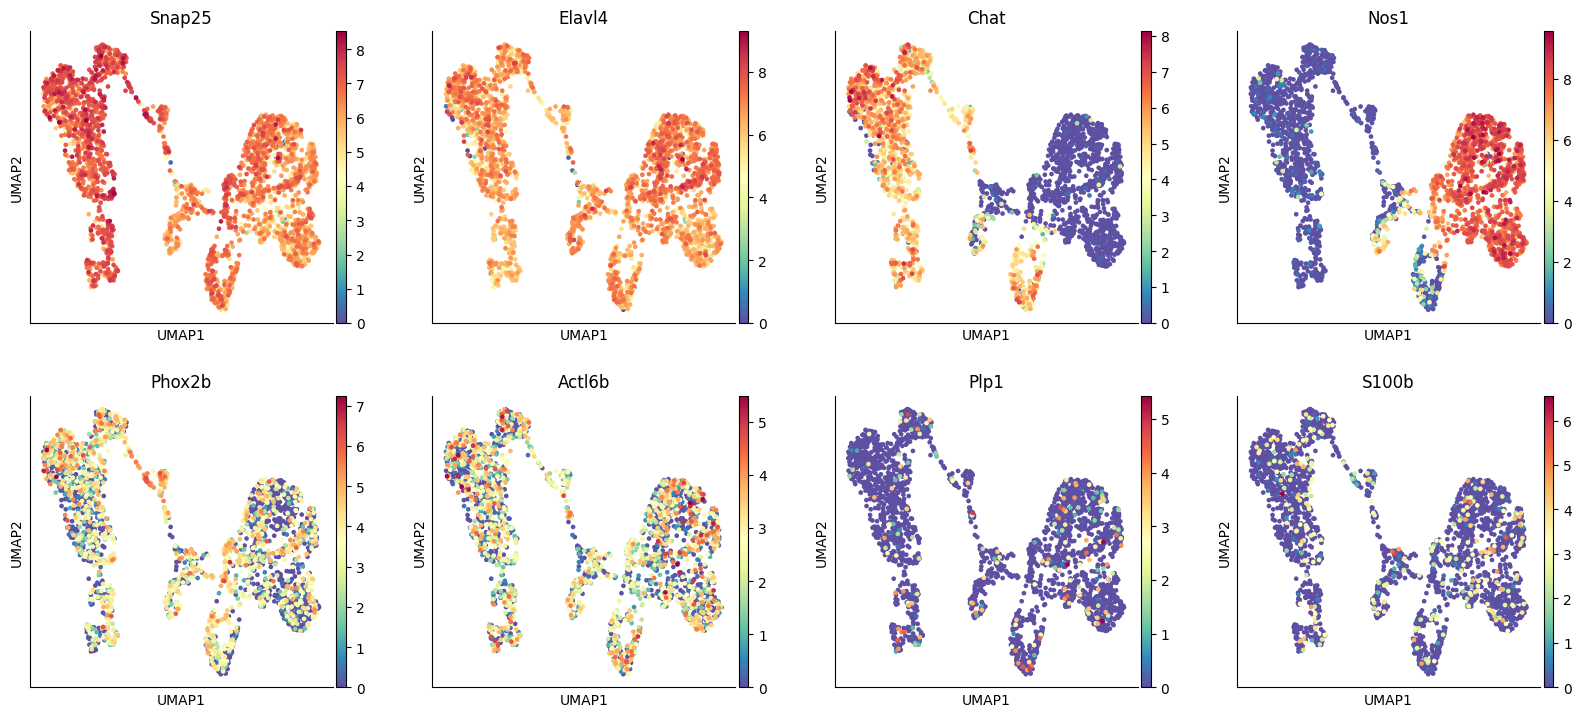

In [23]:
sc.pl.umap(ad_drok_plate, color=["Snap25", "Elavl4", "Chat", "Nos1", "Phox2b", "Actl6b", "Plp1", "S100b"])

In [24]:
drok_metadata_plate_colon = drok_metadata[(drok_metadata['Technology'] == 'Plate')]
drok_metadata_plate_colon = drok_metadata_plate_colon.rename(columns={'Age': 'age'})
drok_metadata_plate_colon = drok_metadata_plate_colon.rename(columns={'Segment (Processed)': 'tissue'})
drok_metadata_plate_colon

,Mouse_ID,sample_id,age,tissue,Sex,Technology,mouse_and_sample_id
0,M1,S1,12,colon,F,Plate,M1_S1
1,M2,S2,12,colon,M,Plate,M2_S2
2,M3,S3,12,colon,M,Plate,M3_S3
3,M4,S4,12,colon,M,Plate,M4_S4
4,M5,S5,12,colon,F,Plate,M5_S5
...,...,...,...,...,...,...,...
96,M28,S98,105,Distal,M,Plate,M28_S98
97,M29,S99,104,Proximal,F,Plate,M29_S99
98,M29,S100,104,Proximal,F,Plate,M29_S100
99,M29,S101,104,Distal,F,Plate,M29_S101


In [25]:
ad_drok_plate.obs['mouse_and_sample_id'].unique()

['M1_S1', 'M2_S2', 'M3_S3', 'M4_S4', 'M5_S5', ..., 'M28_S98', 'M29_S99', 'M29_S100', 'M29_S101', 'M29_S102']
Length: 101
Categories (101, object): ['M1_S1', 'M2_S2', 'M3_S3', 'M4_S4', ..., 'M29_S99', 'M29_S100', 'M29_S101', 'M29_S102']

In [27]:
ad_drok_plate.obs = ad_drok_plate.obs.merge(
    drok_metadata_plate_colon[['mouse_and_sample_id', 'age', 'tissue', 'Sex']],
    on='mouse_and_sample_id',
    how='inner'
)

ad_drok_plate.obs

,barcode,mouse_and_sample_id,mouse_id,sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,age,tissue,Sex
0,Atlas_M1_S1.S339,M1_S1,M1,S1,7060,1.777546e+06,0.0,0.0,0,12,colon,F
1,Atlas_M1_S1.S351,M1_S1,M1,S1,7419,1.435336e+06,0.0,0.0,0,12,colon,F
2,Atlas_M1_S1.S363,M1_S1,M1,S1,7674,1.483152e+06,0.0,0.0,0,12,colon,F
3,Atlas_M1_S1.S349,M1_S1,M1,S1,8018,1.505423e+06,0.0,0.0,0,12,colon,F
4,Atlas_M1_S1.S313,M1_S1,M1,S1,6985,1.412611e+06,0.0,0.0,0,12,colon,F
...,...,...,...,...,...,...,...,...,...,...,...,...
2652,Aging_M29_S102.S329,M29_S102,M29,S102,7639,1.599351e+06,0.0,0.0,11,104,Distal,F
2653,Aging_M29_S102.S302,M29_S102,M29,S102,5302,8.062378e+05,0.0,0.0,1,104,Distal,F
2654,Aging_M29_S102.S307,M29_S102,M29,S102,6454,7.962540e+05,0.0,0.0,3,104,Distal,F
2655,Aging_M29_S102.S321,M29_S102,M29,S102,6775,1.183842e+06,0.0,0.0,7,104,Distal,F


In [28]:
ad_drok_plate.obs = ad_drok_plate.obs.set_index("barcode", drop=False)
ad_drok_plate.obs

,barcode,mouse_and_sample_id,mouse_id,sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,age,tissue,Sex
barcode,,,,,,,,,,,,
Atlas_M1_S1.S339,Atlas_M1_S1.S339,M1_S1,M1,S1,7060,1.777546e+06,0.0,0.0,0,12,colon,F
Atlas_M1_S1.S351,Atlas_M1_S1.S351,M1_S1,M1,S1,7419,1.435336e+06,0.0,0.0,0,12,colon,F
Atlas_M1_S1.S363,Atlas_M1_S1.S363,M1_S1,M1,S1,7674,1.483152e+06,0.0,0.0,0,12,colon,F
Atlas_M1_S1.S349,Atlas_M1_S1.S349,M1_S1,M1,S1,8018,1.505423e+06,0.0,0.0,0,12,colon,F
Atlas_M1_S1.S313,Atlas_M1_S1.S313,M1_S1,M1,S1,6985,1.412611e+06,0.0,0.0,0,12,colon,F
...,...,...,...,...,...,...,...,...,...,...,...,...
Aging_M29_S102.S329,Aging_M29_S102.S329,M29_S102,M29,S102,7639,1.599351e+06,0.0,0.0,11,104,Distal,F
Aging_M29_S102.S302,Aging_M29_S102.S302,M29_S102,M29,S102,5302,8.062378e+05,0.0,0.0,1,104,Distal,F
Aging_M29_S102.S307,Aging_M29_S102.S307,M29_S102,M29,S102,6454,7.962540e+05,0.0,0.0,3,104,Distal,F


In [29]:
ad_drok_plate.write_h5ad('drokhlyansky_plate_preprocessed.h5ad')

# Droplet: Colon

In [30]:
# Load in matrix to an AnnData object
ad_drok_mli = sc.read(input_dir + 'gene_sorted-mli.matrix.mtx')
ad_drok_mli

AnnData object with n_obs × n_vars = 24157 × 343000

In [31]:
barcodes = pd.read_csv(input_dir + 'mli.barcodes.tsv', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [32]:
barcodes['mouse_id'] = barcodes['barcode'].str.split('_').str[0]
barcodes['sample_id'] = barcodes['barcode'].str.split('_').str[1]
barcodes['sample_id'] = barcodes['sample_id'].str.split('.').str[0]
barcodes['mouse_and_sample_id'] = barcodes['mouse_id'] + '_' + barcodes['sample_id']

In [33]:
genes = pd.read_csv(input_dir + 'mli.genes.tsv', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_name'})

In [34]:
ad_drok_mli = ad_drok_mli.T 
ad_drok_mli.obs = barcodes
ad_drok_mli.var = genes
ad_drok_mli.var_names_make_unique()
ad_drok_mli

AnnData object with n_obs × n_vars = 343000 × 24157
    obs: 'barcode', 'mouse_id', 'sample_id', 'mouse_and_sample_id'
    var: 'gene_name'

In [35]:
ad_drok_mli.var_names = ad_drok_mli.var['gene_name']
ad_drok_mli.obs_names = ad_drok_mli.obs['barcode']
ad_drok_mli.layers['raw_counts'] = ad_drok_mli.X.copy()

In [36]:
ad_drok_mli.var["mt"] = ad_drok_mli.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    ad_drok_mli,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

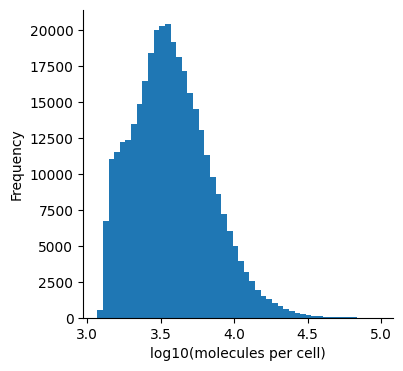

In [37]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_mli.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

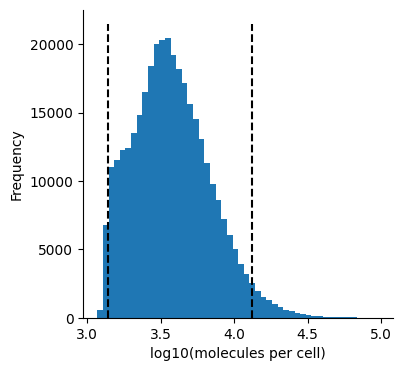

In [38]:
THRESHOLDS = np.log10(np.percentile((ad_drok_mli.obs["total_counts"]), [2, 97]))

plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_mli.obs["total_counts"]), bins=50)
ax.vlines(
    THRESHOLDS,
    ymin=ax.get_ylim()[0],
    ymax=ax.get_ylim()[1],
    color="black",
    linestyle="--",
)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

In [39]:
use_cells = ad_drok_mli.obs_names[
    (np.log10(ad_drok_mli.obs["total_counts"]) > THRESHOLDS[0])
    & (np.log10(ad_drok_mli.obs["total_counts"]) < THRESHOLDS[1])
]
ad_drok_mli = ad_drok_mli[use_cells, :]

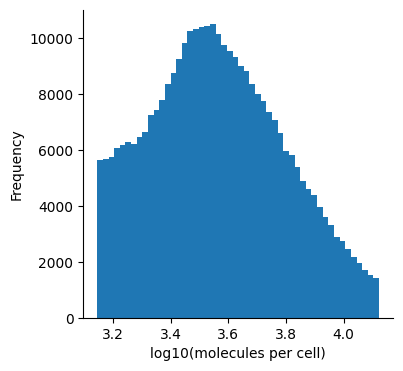

In [40]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_mli.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

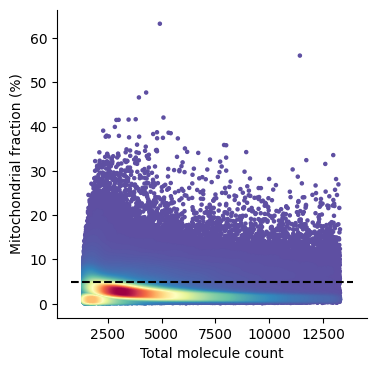

In [41]:
MITO_THRESHOLD = 5
x, y, dens = palantir.plot.density_2d(ad_drok_mli.obs["total_counts"], ad_drok_mli.obs["pct_counts_mt"])

plt.figure()
ax = plt.gca()
ax.scatter(x, y, c=dens, s=5)
ax.hlines(
    MITO_THRESHOLD,
    xmin=ax.get_xlim()[0],
    xmax=ax.get_xlim()[1],
    colors="black",
    linestyles="--",
)
plt.xlabel("Total molecule count")
plt.ylabel("Mitochondrial fraction (%)")
plt.show()

In [42]:
ad_drok_mli = ad_drok_mli[ad_drok_mli.obs["pct_counts_mt"] < MITO_THRESHOLD, :]

In [43]:
sc.pp.filter_genes(ad_drok_mli, min_cells=50)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:284: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [44]:
ad_drok_mli.shape

(266515, 21240)

In [45]:
sc.pp.normalize_total(ad_drok_mli, target_sum=1e4)
ad_drok_mli.layers["normalized_counts"] = ad_drok_mli.X.copy()
log_transform(ad_drok_mli)
ad_drok_mli.layers["logcounts"] = ad_drok_mli.X.copy()

In [46]:
sc.pp.highly_variable_genes(ad_drok_mli, flavor="cell_ranger", n_top_genes=2500)

In [47]:
sc.tl.pca(ad_drok_mli, mask_var="highly_variable")

In [48]:
sc.pp.neighbors(ad_drok_mli, use_rep="X_pca")
sc.tl.umap(ad_drok_mli)

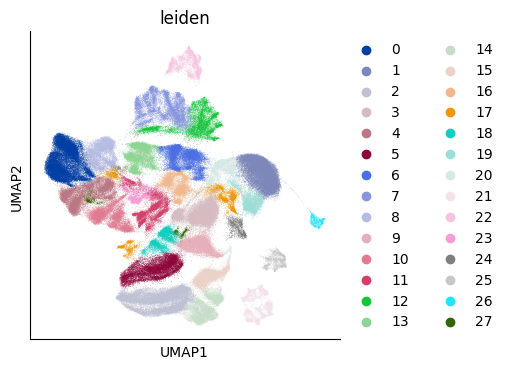

In [49]:
sc.tl.leiden(ad_drok_mli, resolution=0.6, key_added="leiden")
sc.pl.umap(ad_drok_mli, color="leiden")

In [50]:
gene_list = ["Tubb3", "Elavl4", "Ret", "Phox2b", "Chrnb4", "Eml5", "Smpd3", "Tagln3", "Snap25", "Gpr22", "Gdap1l1", "Stmn3", "Chrna3", "Scg3", "Syt4", "Ncan", "Crmp1", "Adcyap1r1", "Elavl3", "Dlg2", "Cacna2d"]
sc.tl.score_genes(ad_drok_mli, gene_list, score_name='ENS score')

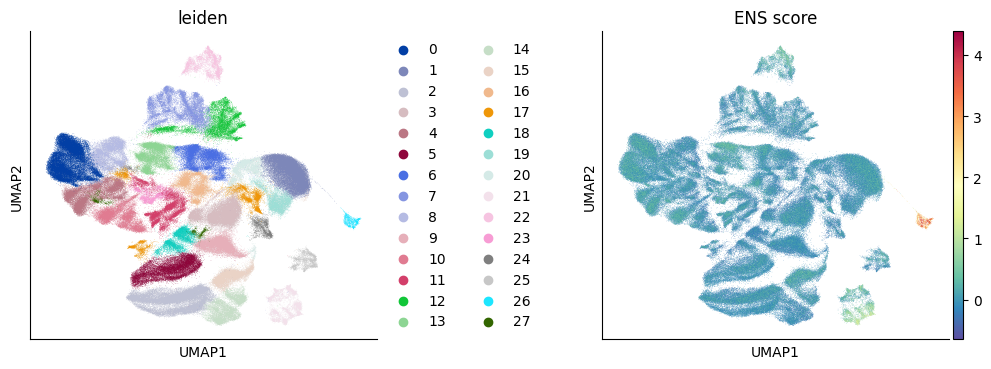

In [51]:
sc.pl.umap(ad_drok_mli, color=["leiden", "ENS score"], wspace=0.5)

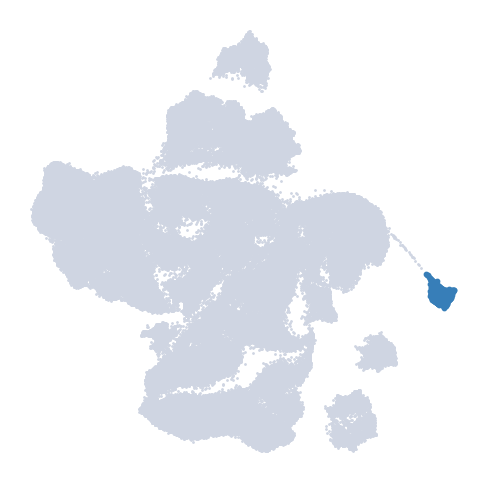

In [52]:
cells = ad_drok_mli.obs_names[ad_drok_mli.obs["leiden"] == '26']
palantir.plot.highlight_cells_on_umap(ad_drok_mli, cells)
plt.show()

In [53]:
ad_drok_mli_neur = ad_drok_mli[ad_drok_mli.obs['leiden'] == '26'].copy()

In [54]:
sc.pp.highly_variable_genes(ad_drok_mli_neur, flavor="cell_ranger", n_top_genes=2500)

In [55]:
sc.tl.pca(ad_drok_mli_neur, mask_var="highly_variable")

In [56]:
sc.pp.neighbors(ad_drok_mli_neur, use_rep="X_pca")
sc.tl.umap(ad_drok_mli_neur)

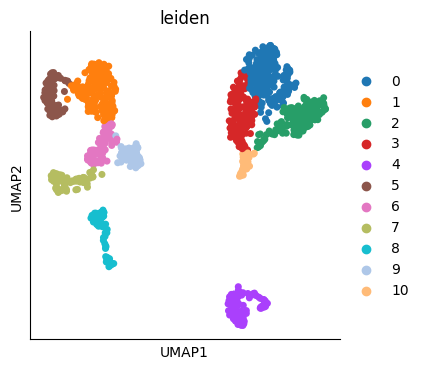

In [57]:
sc.tl.leiden(ad_drok_mli_neur, resolution=0.6, key_added="leiden")
sc.pl.umap(ad_drok_mli_neur, color="leiden")

In [58]:
ad_drok_mli_neur.shape

(1174, 21240)

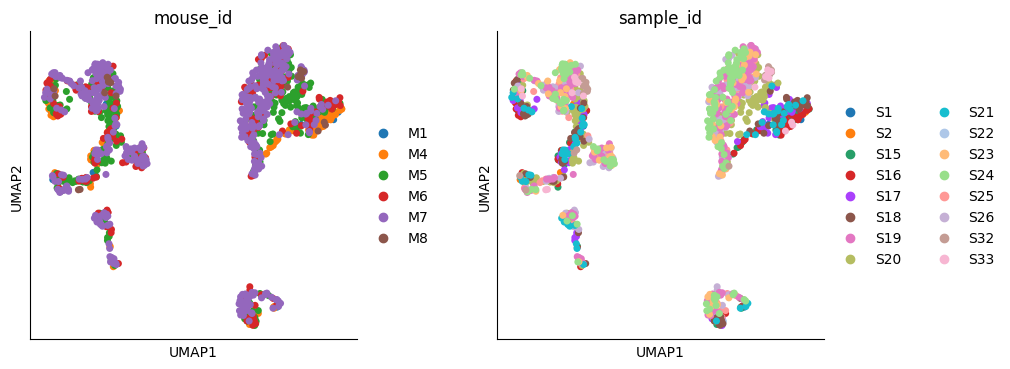

In [59]:
sc.pl.umap(ad_drok_mli_neur, color=["mouse_id", "sample_id"], wspace=0.3)

In [60]:
ad_drok_mli_neur_corrected = ad_drok_mli_neur.copy()

In [61]:
sc.external.pp.harmony_integrate(ad_drok_mli_neur_corrected, key='mouse_id', max_iter_harmony=10)

2025-11-21 11:20:39,156 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-21 11:20:40,210 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-21 11:20:40,227 - harmonypy - INFO - Iteration 1 of 10
2025-11-21 11:20:40,930 - harmonypy - INFO - Iteration 2 of 10
2025-11-21 11:20:41,501 - harmonypy - INFO - Iteration 3 of 10
2025-11-21 11:20:42,063 - harmonypy - INFO - Iteration 4 of 10
2025-11-21 11:20:42,326 - harmonypy - INFO - Iteration 5 of 10
2025-11-21 11:20:42,536 - harmonypy - INFO - Iteration 6 of 10
2025-11-21 11:20:42,682 - harmonypy - INFO - Iteration 7 of 10
2025-11-21 11:20:42,838 - harmonypy - INFO - Converged after 7 iterations


In [62]:
sc.pp.neighbors(ad_drok_mli_neur_corrected, use_rep='X_pca_harmony')
sc.tl.umap(ad_drok_mli_neur_corrected)
sc.tl.leiden(ad_drok_mli_neur_corrected)

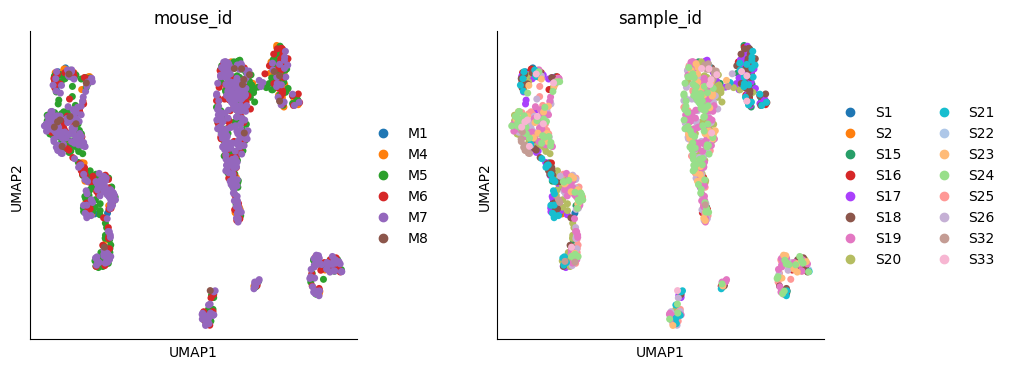

In [63]:
sc.pl.umap(ad_drok_mli_neur_corrected, color=["mouse_id", "sample_id"], wspace=0.3)

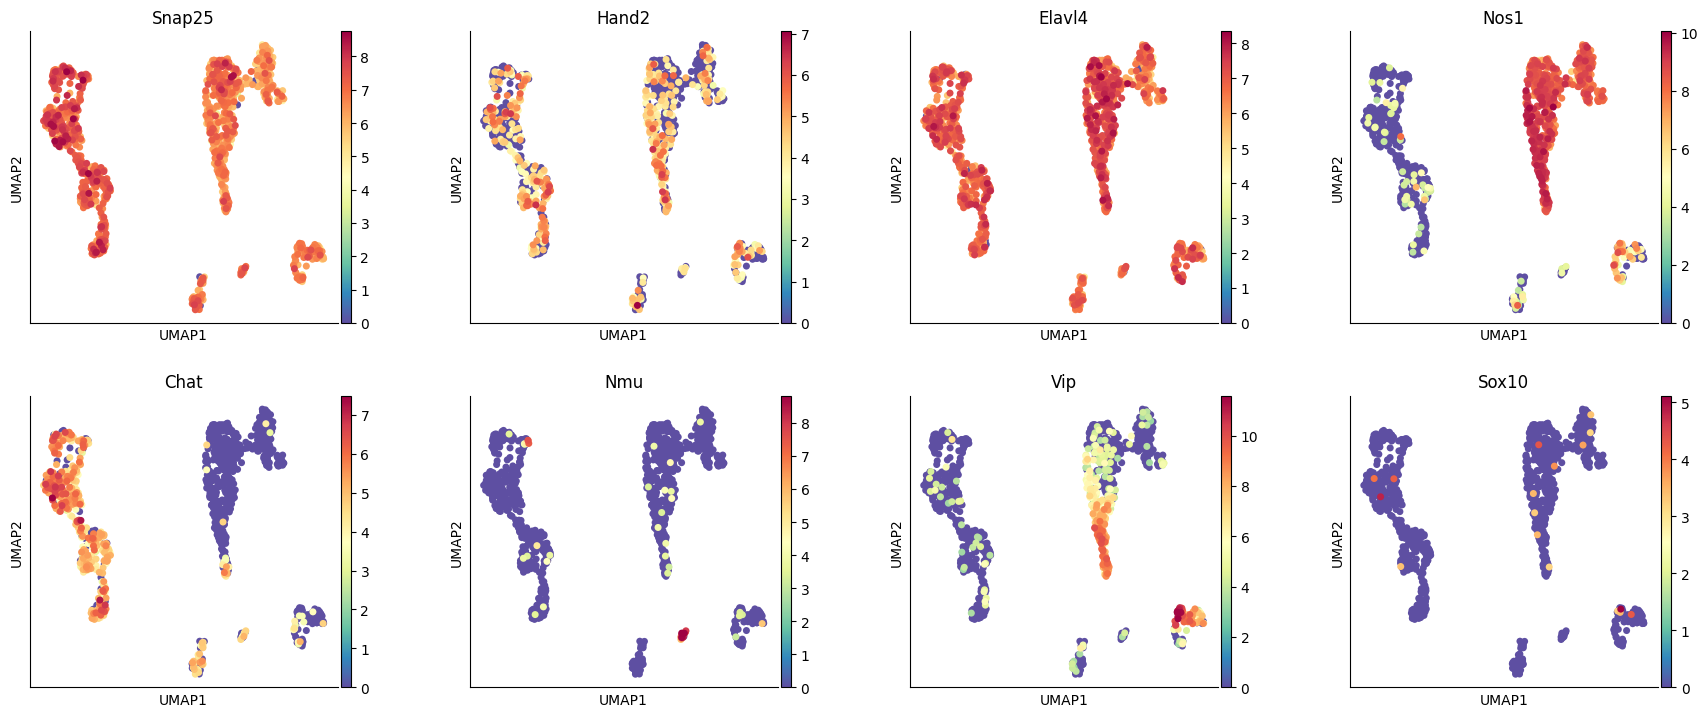

In [64]:
sc.pl.umap(ad_drok_mli_neur_corrected, color=["Snap25", "Hand2", "Elavl4", "Nos1", "Chat", "Nmu", "Vip", "Sox10"], wspace=0.3)

In [65]:
ad_drok_mli_neur_corrected.obs['dataset'] = 'Drokhlyansky Droplet Colon'

In [66]:
drok_metadata_droplet_colon = drok_metadata[(drok_metadata['Technology'] == 'Droplet') & (drok_metadata['Segment (Processed)'] == 'colon')]
drok_metadata_droplet_colon = drok_metadata_droplet_colon.rename(columns={'Age': 'age'})
drok_metadata_droplet_colon = drok_metadata_droplet_colon.rename(columns={'Segment (Processed)': 'tissue'})
drok_metadata_droplet_colon

,Mouse_ID,sample_id,age,tissue,Sex,Technology,mouse_and_sample_id
101,M1,S1,12,colon,F,Droplet,M1_S1
102,M1,S2,12,colon,F,Droplet,M1_S2
103,M4,S15,12,colon,M,Droplet,M4_S15
104,M4,S16,12,colon,M,Droplet,M4_S16
105,M5,S17,12,colon,M,Droplet,M5_S17
106,M5,S20,12,colon,M,Droplet,M5_S20
107,M5,S22,12,colon,M,Droplet,M5_S22
108,M5,S25,12,colon,M,Droplet,M5_S25
109,M6,S18,12,colon,M,Droplet,M6_S18
110,M6,S26,12,colon,M,Droplet,M6_S26


In [67]:
ad_drok_mli_neur_corrected.obs['mouse_and_sample_id'].unique()

['M1_S1', 'M1_S2', 'M4_S15', 'M4_S16', 'M5_S17', ..., 'M7_S21', 'M7_S23', 'M7_S24', 'M7_S32', 'M8_S33']
Length: 16
Categories (16, object): ['M1_S1', 'M1_S2', 'M4_S15', 'M4_S16', ..., 'M7_S23', 'M7_S24', 'M7_S32', 'M8_S33']

In [69]:
ad_drok_mli_neur_corrected.obs = ad_drok_mli_neur_corrected.obs.merge(
    drok_metadata_droplet_colon[['mouse_and_sample_id', 'age', 'tissue', 'Sex']],
    on='mouse_and_sample_id',
    how='inner'
)

ad_drok_mli_neur_corrected.obs

,barcode,mouse_id,sample_id,mouse_and_sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,ENS score,dataset,age,tissue,Sex
0,M1_S1.AGACCCGGTCGACTGC,M1,S1,M1_S1,3063,7273.0,338.0,4.647326,4,2.977340,Drokhlyansky Droplet Colon,12,colon,F
1,M1_S1.CATGCCTAGCATTTCG,M1,S1,M1_S1,4127,10942.0,417.0,3.811004,4,4.223154,Drokhlyansky Droplet Colon,12,colon,F
2,M1_S1.AAGTCGTCAGAACTTC,M1,S1,M1_S1,2021,3950.0,16.0,0.405063,8,2.906654,Drokhlyansky Droplet Colon,12,colon,F
3,M1_S1.AAGACTCTCGTCAAAC,M1,S1,M1_S1,2948,6338.0,225.0,3.550016,7,3.136423,Drokhlyansky Droplet Colon,12,colon,F
4,M1_S1.CAGGGCTTCCGTACGG,M1,S1,M1_S1,2486,5448.0,15.0,0.275330,13,1.957393,Drokhlyansky Droplet Colon,12,colon,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,M8_S33.AAAGTAGCATTGAGCT,M8,S33,M8_S33,1508,2303.0,64.0,2.778984,1,2.592419,Drokhlyansky Droplet Colon,12,colon,M
1170,M8_S33.GCTCTGTCAAGTAGTA,M8,S33,M8_S33,1037,1467.0,42.0,2.862986,9,1.634929,Drokhlyansky Droplet Colon,12,colon,M
1171,M8_S33.CGGACTGGTACCGAGA,M8,S33,M8_S33,1517,2317.0,10.0,0.431593,0,2.246829,Drokhlyansky Droplet Colon,12,colon,M
1172,M8_S33.TGGTTAGCAGTCAGAG,M8,S33,M8_S33,1407,2096.0,16.0,0.763359,8,1.506041,Drokhlyansky Droplet Colon,12,colon,M


In [70]:
ad_drok_mli_neur_corrected.obs = ad_drok_mli_neur_corrected.obs.set_index("barcode", drop=False)
ad_drok_mli_neur_corrected.obs

,barcode,mouse_id,sample_id,mouse_and_sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,ENS score,dataset,age,tissue,Sex
barcode,,,,,,,,,,,,,,
M1_S1.AGACCCGGTCGACTGC,M1_S1.AGACCCGGTCGACTGC,M1,S1,M1_S1,3063,7273.0,338.0,4.647326,4,2.977340,Drokhlyansky Droplet Colon,12,colon,F
M1_S1.CATGCCTAGCATTTCG,M1_S1.CATGCCTAGCATTTCG,M1,S1,M1_S1,4127,10942.0,417.0,3.811004,4,4.223154,Drokhlyansky Droplet Colon,12,colon,F
M1_S1.AAGTCGTCAGAACTTC,M1_S1.AAGTCGTCAGAACTTC,M1,S1,M1_S1,2021,3950.0,16.0,0.405063,8,2.906654,Drokhlyansky Droplet Colon,12,colon,F
M1_S1.AAGACTCTCGTCAAAC,M1_S1.AAGACTCTCGTCAAAC,M1,S1,M1_S1,2948,6338.0,225.0,3.550016,7,3.136423,Drokhlyansky Droplet Colon,12,colon,F
M1_S1.CAGGGCTTCCGTACGG,M1_S1.CAGGGCTTCCGTACGG,M1,S1,M1_S1,2486,5448.0,15.0,0.275330,13,1.957393,Drokhlyansky Droplet Colon,12,colon,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M8_S33.AAAGTAGCATTGAGCT,M8_S33.AAAGTAGCATTGAGCT,M8,S33,M8_S33,1508,2303.0,64.0,2.778984,1,2.592419,Drokhlyansky Droplet Colon,12,colon,M
M8_S33.GCTCTGTCAAGTAGTA,M8_S33.GCTCTGTCAAGTAGTA,M8,S33,M8_S33,1037,1467.0,42.0,2.862986,9,1.634929,Drokhlyansky Droplet Colon,12,colon,M
M8_S33.CGGACTGGTACCGAGA,M8_S33.CGGACTGGTACCGAGA,M8,S33,M8_S33,1517,2317.0,10.0,0.431593,0,2.246829,Drokhlyansky Droplet Colon,12,colon,M


In [107]:
ad_drok_mli_neur_corrected.write_h5ad('drokhlyansky_droplet_colon_preprocessed.h5ad')

# Droplet: Ileum

In [72]:
# Load in matrix to an AnnData object
ad_drok_msi = sc.read(input_dir + 'gene_sorted-msi.matrix.mtx')
ad_drok_msi

AnnData object with n_obs × n_vars = 22595 × 79293

In [73]:
barcodes = pd.read_csv(input_dir + 'msi.barcodes.tsv', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [74]:
barcodes['mouse_id'] = barcodes['barcode'].str.split('_').str[0]
barcodes['sample_id'] = barcodes['barcode'].str.split('_').str[1]
barcodes['sample_id'] = barcodes['sample_id'].str.split('.').str[0]
barcodes['mouse_and_sample_id'] = barcodes['mouse_id'] + '_' + barcodes['sample_id']

In [75]:
genes = pd.read_csv(input_dir + 'msi.genes.tsv', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_name'})

In [76]:
ad_drok_msi = ad_drok_msi.T 
ad_drok_msi.obs = barcodes
ad_drok_msi.var = genes
ad_drok_msi.var_names_make_unique()
ad_drok_msi

AnnData object with n_obs × n_vars = 79293 × 22595
    obs: 'barcode', 'mouse_id', 'sample_id', 'mouse_and_sample_id'
    var: 'gene_name'

In [77]:
ad_drok_msi.var_names = ad_drok_msi.var['gene_name']
ad_drok_msi.obs_names = ad_drok_msi.obs['barcode']
ad_drok_msi.layers['raw_counts'] = ad_drok_msi.X.copy()

In [78]:
ad_drok_msi.var["mt"] = ad_drok_msi.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    ad_drok_msi,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

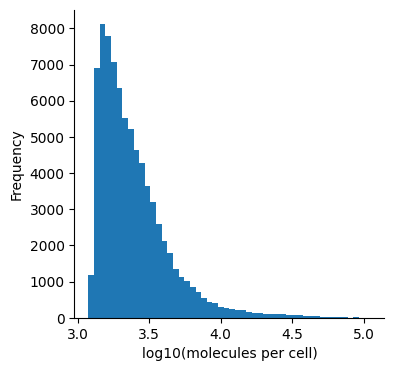

In [79]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_msi.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

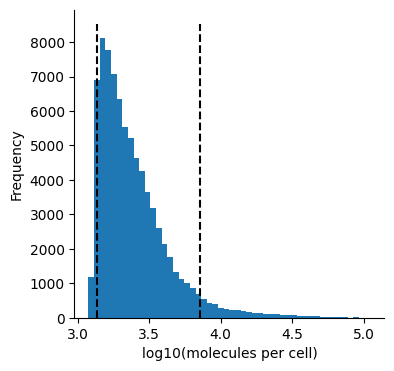

In [80]:
THRESHOLDS = np.log10(np.percentile((ad_drok_msi.obs["total_counts"]), [5, 95]))

plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_msi.obs["total_counts"]), bins=50)
ax.vlines(
    THRESHOLDS,
    ymin=ax.get_ylim()[0],
    ymax=ax.get_ylim()[1],
    color="black",
    linestyle="--",
)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

In [81]:
use_cells = ad_drok_msi.obs_names[
    (np.log10(ad_drok_msi.obs["total_counts"]) > THRESHOLDS[0])
    & (np.log10(ad_drok_msi.obs["total_counts"]) < THRESHOLDS[1])
]
ad_drok_msi = ad_drok_msi[use_cells, :]

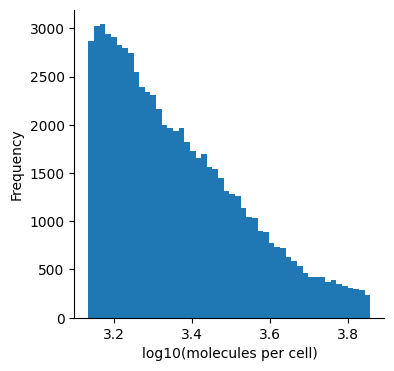

In [82]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_drok_msi.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

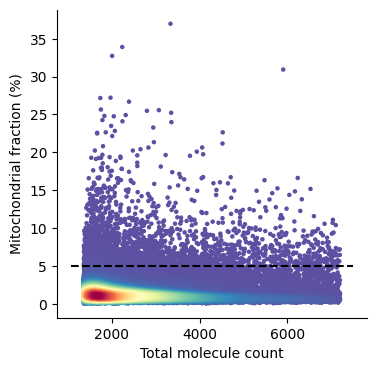

In [83]:
MITO_THRESHOLD = 5
x, y, dens = palantir.plot.density_2d(ad_drok_msi.obs["total_counts"], ad_drok_msi.obs["pct_counts_mt"])

plt.figure()
ax = plt.gca()
ax.scatter(x, y, c=dens, s=5)
ax.hlines(
    MITO_THRESHOLD,
    xmin=ax.get_xlim()[0],
    xmax=ax.get_xlim()[1],
    colors="black",
    linestyles="--",
)
plt.xlabel("Total molecule count")
plt.ylabel("Mitochondrial fraction (%)")
plt.show()

In [84]:
ad_drok_msi = ad_drok_msi[ad_drok_msi.obs["pct_counts_mt"] < MITO_THRESHOLD, :]

In [85]:
sc.pp.filter_genes(ad_drok_msi, min_cells=50)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:284: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [86]:
ad_drok_msi.shape

(69249, 17595)

In [87]:
sc.pp.normalize_total(ad_drok_msi, target_sum=1e4)
ad_drok_msi.layers["normalized_counts"] = ad_drok_msi.X.copy()
log_transform(ad_drok_msi)
ad_drok_msi.layers["logcounts"] = ad_drok_msi.X.copy()

In [88]:
sc.pp.highly_variable_genes(ad_drok_msi, flavor="cell_ranger", n_top_genes=2500)

In [89]:
sc.tl.pca(ad_drok_msi, mask_var="highly_variable")

In [90]:
sc.pp.neighbors(ad_drok_msi, use_rep="X_pca")
sc.tl.umap(ad_drok_msi)

IOStream.flush timed out
IOStream.flush timed out


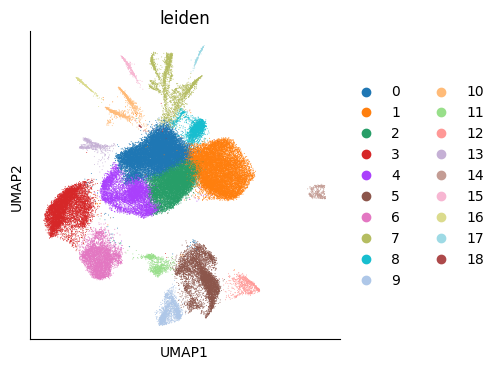

In [91]:
sc.tl.leiden(ad_drok_msi, resolution=0.6, key_added="leiden")
sc.pl.umap(ad_drok_msi, color="leiden")

In [92]:
gene_list = ["Tubb3", "Elavl4", "Ret", "Phox2b", "Chrnb4", "Eml5", "Smpd3", "Tagln3", "Snap25", "Gpr22", "Gdap1l1", "Stmn3", "Chrna3", "Scg3", "Syt4", "Ncan", "Crmp1", "Adcyap1r1", "Elavl3", "Dlg2", "Cacna2d"]
sc.tl.score_genes(ad_drok_msi, gene_list, score_name='ENS score')

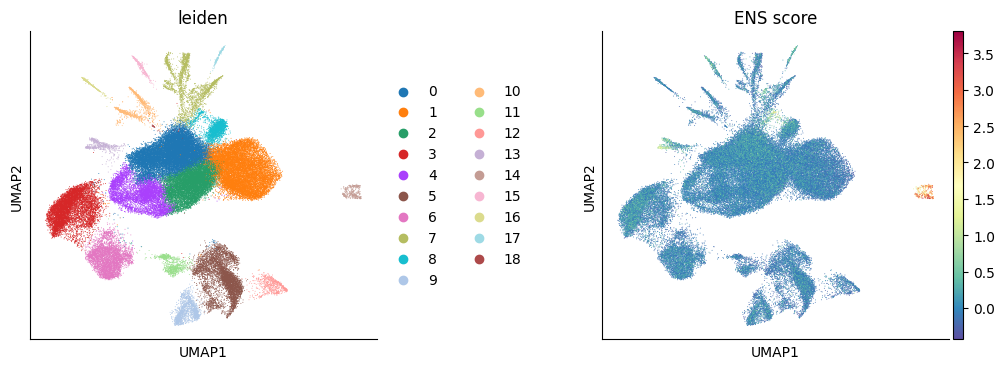

In [93]:
sc.pl.umap(ad_drok_msi, color=["leiden", "ENS score"], wspace=0.5)

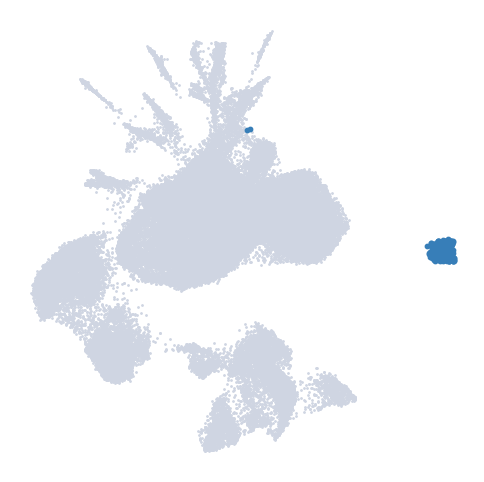

In [94]:
cells = ad_drok_msi.obs_names[ad_drok_msi.obs["leiden"] == '14']
palantir.plot.highlight_cells_on_umap(ad_drok_msi, cells)
plt.show()

In [95]:
ad_drok_msi_neur = ad_drok_msi[ad_drok_msi.obs['leiden'] == '14'].copy()

In [96]:
sc.pp.highly_variable_genes(ad_drok_msi_neur, flavor="cell_ranger", n_top_genes=2500)

In [97]:
sc.tl.pca(ad_drok_msi_neur, mask_var="highly_variable")

In [98]:
sc.pp.neighbors(ad_drok_msi_neur, use_rep="X_pca")
sc.tl.umap(ad_drok_msi_neur)

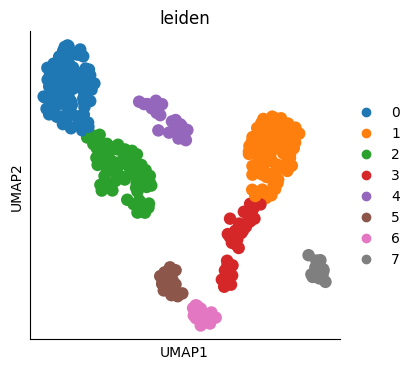

In [99]:
sc.tl.leiden(ad_drok_msi_neur, resolution=0.6, key_added="leiden")
sc.pl.umap(ad_drok_msi_neur, color="leiden")

In [100]:
ad_drok_msi_neur.shape

(372, 17595)

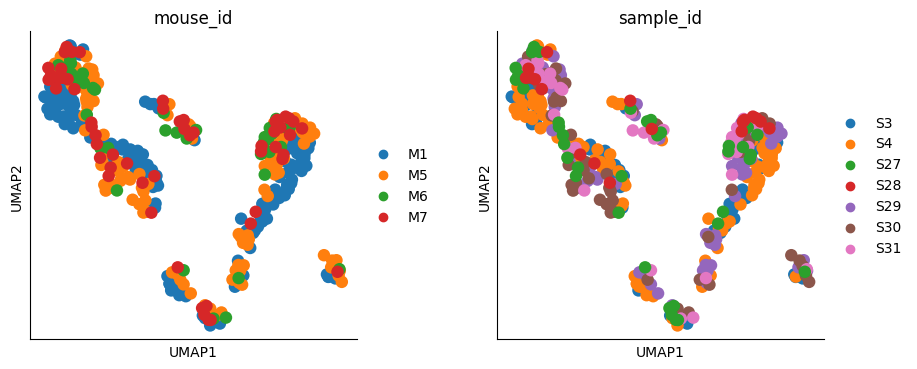

In [101]:
sc.pl.umap(ad_drok_msi_neur, color=["mouse_id", "sample_id"], wspace=0.3)

In [102]:
ad_drok_msi_neur_corrected = ad_drok_msi_neur.copy()

In [103]:
sc.external.pp.harmony_integrate(ad_drok_msi_neur_corrected, key='mouse_id', max_iter_harmony=10)

2025-11-21 11:37:47,564 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-21 11:37:47,790 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-21 11:37:47,792 - harmonypy - INFO - Iteration 1 of 10
2025-11-21 11:37:47,823 - harmonypy - INFO - Iteration 2 of 10
2025-11-21 11:37:47,848 - harmonypy - INFO - Iteration 3 of 10
2025-11-21 11:37:47,868 - harmonypy - INFO - Iteration 4 of 10
2025-11-21 11:37:47,880 - harmonypy - INFO - Iteration 5 of 10
2025-11-21 11:37:47,892 - harmonypy - INFO - Iteration 6 of 10
2025-11-21 11:37:47,905 - harmonypy - INFO - Iteration 7 of 10
2025-11-21 11:37:47,917 - harmonypy - INFO - Converged after 7 iterations


In [104]:
sc.pp.neighbors(ad_drok_msi_neur_corrected, use_rep='X_pca_harmony')
sc.tl.umap(ad_drok_msi_neur_corrected)
sc.tl.leiden(ad_drok_msi_neur_corrected)

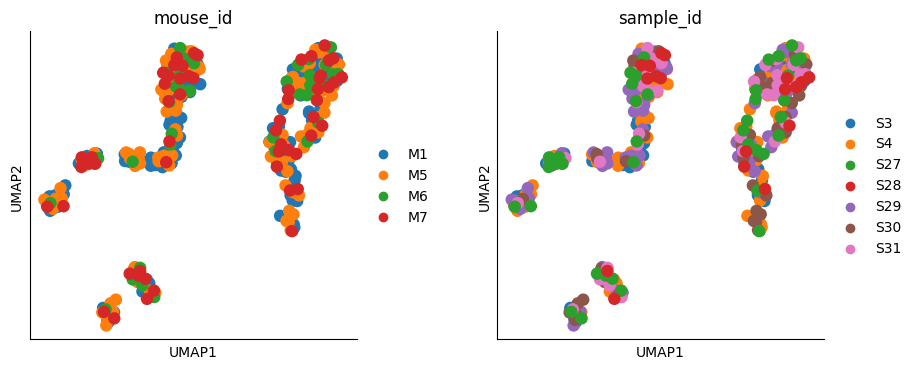

In [105]:
sc.pl.umap(ad_drok_msi_neur_corrected, color=["mouse_id", "sample_id"], wspace=0.3)

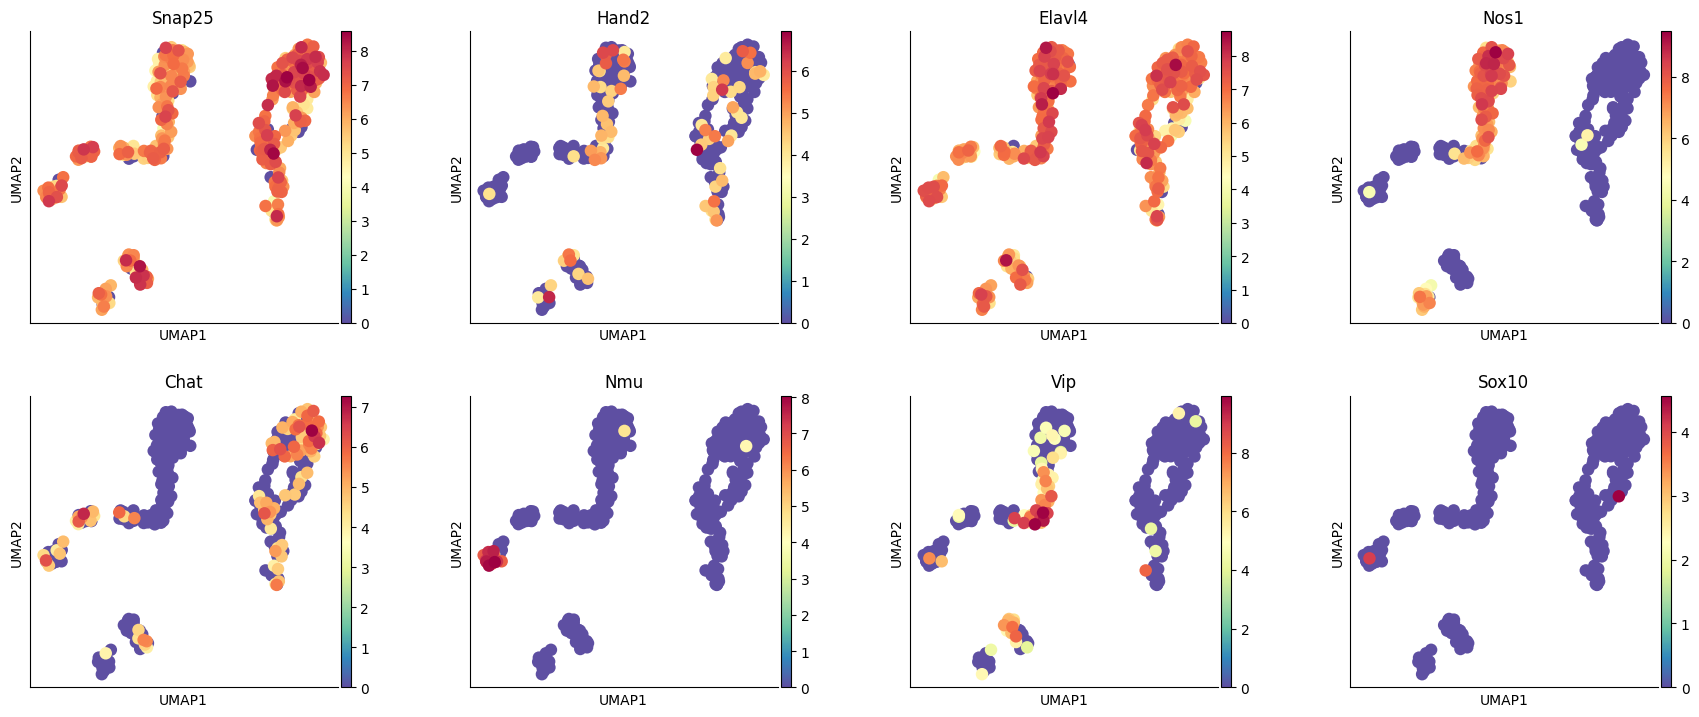

In [106]:
sc.pl.umap(ad_drok_msi_neur_corrected, color=["Snap25", "Hand2", "Elavl4", "Nos1", "Chat", "Nmu", "Vip", "Sox10"], wspace=0.3)

In [108]:
ad_drok_msi_neur_corrected.obs['dataset'] = 'Drokhlyanksy Droplet Ileum'

In [109]:
drok_metadata_droplet_ileum = drok_metadata[(drok_metadata['Technology'] == 'Droplet') & (drok_metadata['Segment (Processed)'] == 'ileum')]
drok_metadata_droplet_ileum = drok_metadata_droplet_ileum.rename(columns={'Age': 'age'})
drok_metadata_droplet_ileum = drok_metadata_droplet_ileum.rename(columns={'Segment (Processed)': 'tissue'})
drok_metadata_droplet_ileum

,Mouse_ID,sample_id,age,tissue,Sex,Technology,mouse_and_sample_id
117,M1,S3,12,ileum,F,Droplet,M1_S3
118,M1,S4,12,ileum,F,Droplet,M1_S4
119,M5,S29,12,ileum,F,Droplet,M5_S29
120,M5,S30,12,ileum,F,Droplet,M5_S30
121,M6,S31,12,ileum,M,Droplet,M6_S31
122,M7,S27,12,ileum,F,Droplet,M7_S27
123,M7,S28,12,ileum,F,Droplet,M7_S28


In [110]:
ad_drok_msi_neur_corrected.obs['mouse_and_sample_id'].unique()

['M1_S3', 'M1_S4', 'M5_S29', 'M5_S30', 'M6_S31', 'M7_S27', 'M7_S28']
Categories (7, object): ['M1_S3', 'M1_S4', 'M5_S29', 'M5_S30', 'M6_S31', 'M7_S27', 'M7_S28']

In [112]:
ad_drok_msi_neur_corrected.obs = ad_drok_msi_neur_corrected.obs.merge(
    drok_metadata_droplet_ileum[['mouse_and_sample_id', 'age', 'tissue', 'Sex']],
    on='mouse_and_sample_id',
    how='inner'
)

ad_drok_msi_neur_corrected.obs

,barcode,mouse_id,sample_id,mouse_and_sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,ENS score,dataset,age,tissue,Sex
0,M1_S3.ACATCCCAGCCAGAGT,M1,S3,M1_S3,1586,2754.0,9.0,0.326797,1,1.976156,Drokhlyanksy Droplet Ileum,12,ileum,F
1,M1_S3.TAATCTCCACCCATAA,M1,S3,M1_S3,1939,3889.0,4.0,0.102854,0,1.332519,Drokhlyanksy Droplet Ileum,12,ileum,F
2,M1_S3.GTCATGACATGTGCCG,M1,S3,M1_S3,2543,5451.0,189.0,3.467254,3,3.707939,Drokhlyanksy Droplet Ileum,12,ileum,F
3,M1_S3.AAGATAGTCAGGTAAA,M1,S3,M1_S3,1445,2370.0,7.0,0.295359,1,2.420972,Drokhlyanksy Droplet Ileum,12,ileum,F
4,M1_S3.TGGATCAGTCATAAAG,M1,S3,M1_S3,2051,3700.0,18.0,0.486486,8,3.456730,Drokhlyanksy Droplet Ileum,12,ileum,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,M7_S28.AAGTCGTGTCTTTCAT,M7,S28,M7_S28,2136,4050.0,26.0,0.641975,1,2.397237,Drokhlyanksy Droplet Ileum,12,ileum,F
368,M7_S28.GAAGCGAGTTGCACGC,M7,S28,M7_S28,2901,6603.0,47.0,0.711798,1,3.069038,Drokhlyanksy Droplet Ileum,12,ileum,F
369,M7_S28.CTTAGGAAGGTACAAT,M7,S28,M7_S28,2460,5556.0,38.0,0.683945,0,2.233254,Drokhlyanksy Droplet Ileum,12,ileum,F
370,M7_S28.TGTCCCATCTCATGGA,M7,S28,M7_S28,2786,6374.0,43.0,0.674616,0,2.881755,Drokhlyanksy Droplet Ileum,12,ileum,F


In [113]:
ad_drok_msi_neur_corrected.obs = ad_drok_msi_neur_corrected.obs.set_index("barcode", drop=False)
ad_drok_msi_neur_corrected.obs

,barcode,mouse_id,sample_id,mouse_and_sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,ENS score,dataset,age,tissue,Sex
barcode,,,,,,,,,,,,,,
M1_S3.ACATCCCAGCCAGAGT,M1_S3.ACATCCCAGCCAGAGT,M1,S3,M1_S3,1586,2754.0,9.0,0.326797,1,1.976156,Drokhlyanksy Droplet Ileum,12,ileum,F
M1_S3.TAATCTCCACCCATAA,M1_S3.TAATCTCCACCCATAA,M1,S3,M1_S3,1939,3889.0,4.0,0.102854,0,1.332519,Drokhlyanksy Droplet Ileum,12,ileum,F
M1_S3.GTCATGACATGTGCCG,M1_S3.GTCATGACATGTGCCG,M1,S3,M1_S3,2543,5451.0,189.0,3.467254,3,3.707939,Drokhlyanksy Droplet Ileum,12,ileum,F
M1_S3.AAGATAGTCAGGTAAA,M1_S3.AAGATAGTCAGGTAAA,M1,S3,M1_S3,1445,2370.0,7.0,0.295359,1,2.420972,Drokhlyanksy Droplet Ileum,12,ileum,F
M1_S3.TGGATCAGTCATAAAG,M1_S3.TGGATCAGTCATAAAG,M1,S3,M1_S3,2051,3700.0,18.0,0.486486,8,3.456730,Drokhlyanksy Droplet Ileum,12,ileum,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M7_S28.AAGTCGTGTCTTTCAT,M7_S28.AAGTCGTGTCTTTCAT,M7,S28,M7_S28,2136,4050.0,26.0,0.641975,1,2.397237,Drokhlyanksy Droplet Ileum,12,ileum,F
M7_S28.GAAGCGAGTTGCACGC,M7_S28.GAAGCGAGTTGCACGC,M7,S28,M7_S28,2901,6603.0,47.0,0.711798,1,3.069038,Drokhlyanksy Droplet Ileum,12,ileum,F
M7_S28.CTTAGGAAGGTACAAT,M7_S28.CTTAGGAAGGTACAAT,M7,S28,M7_S28,2460,5556.0,38.0,0.683945,0,2.233254,Drokhlyanksy Droplet Ileum,12,ileum,F


In [114]:
ad_drok_mli_neur_corrected.write_h5ad('drokhlyansky_droplet_ileum_preprocessed.h5ad')